<center>
<img src="https://drive.google.com/uc?id=1f1gGVI-rxcHjA90WEGNvvtSXF1pAxQwg" alt="Fasilkom UI" width="300"/>

CSCE604037 • Penambangan Data

Semester Genap 2024/2025

Fakultas Ilmu Komputer, Universitas Indonesia

## **Lab 2: *Tabular Data Mining***

### **Tenggat Waktu: 15 Februari 2025, 23.59 WIB**
</center>

### **Ketentuan:**

1. Dokumen *template* lab dengan format .ipynb dan dataset (jika dibutuhkan) telah disediakan di SCeLe
2. Jalankan kode pada dokumen .ipynb dan perhatikan dengan saksama apa yang potongan kode tersebut lakukan beserta dengan keluarannya. Jawablah pertanyaan yang disisipkan pada potongan program yang diberikan.
3. Dokumen Jupyter Notebook yang telah dilengkapi dengan jawaban dikumpulkan dengan format penamaan **Kelas_LabX_NPM_Nama.ipynb**. Contoh: A_Lab2_2106752180_AlvaroAustin.ipynb
4. Kumpulkan dokumen tersebut pada submisi yang telah disediakan di SCeLe sebelum tenggat waktu yang ditentukan. Keterlambatan pengumpulan akan dikenakan penalti sebanyak **satu poin per menit**.
5. Lab ini dirancang sebagai **tugas mandiri**. Plagiarisme tidak diperkenankan dalam bentuk apapun. Adapun kolaborasi berupa diskusi (tanpa menyalin maupun mengambil jawaban orang lain) dan literasi masih diperbolehkan dengan mencantumkan kolaborator dan sumber.

**Nama**: Mohamad Arvin Fadriansyah

**Kelas**: A

**NPM**: 2006596996

**Kolaborator** (jika ada):
- Nama (NPM)

**Referensi** (jika ada):
- [Referensi](https://example.com)

In [63]:
# !pip install duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import sqlite3

## Deskripsi Tugas: Tabular Data Mining untuk Database Toko Buku Online

Perusahaan BiblioNest adalah sebuah platform toko buku online yang memungkinkan pengguna untuk menjelajahi, membeli, dan membaca ulasan tentang berbagai buku dari berbagai kategori dan penulis. Dalam beberapa bulan terakhir, tim pengembang BiblioNest menyadari bahwa mereka membutuhkan sistem penyimpanan data yang lebih terstruktur untuk mendukung pertumbuhan database mereka, terutama dalam hal pencarian data yang lebih cepat, manajemen hubungan antar data, dan analisis tren pembelian.

Saat ini, data buku, penulis, dan kategori belum terorganisir dengan baik, sehingga sering terjadi kesulitan dalam menampilkan informasi yang relevan kepada pelanggan. Selain itu, mereka juga ingin dapat melakukan analisis data terkait tren penulis populer, kategori buku yang paling banyak diminati, serta hubungan antara tahun terbit dengan preferensi pelanggan.



## Tugas Anda
Sebagai seorang analis data yang bertanggung jawab atas proyek ini, tugas Anda adalah:

- Merancang struktur database yang sesuai untuk menyimpan dan mengelola data buku, penulis, dan kategorinya.
- Menggunakan teknik tabular data mining untuk mengekstrak informasi yang berguna dari database tersebut.
- Memberikan rekomendasi terkait bagaimana struktur database ini dapat membantu tim BiblioNest dalam pengambilan keputusan bisnis.

## 📚 Informasi Data pada Sistem BiblioNest

Sistem **BiblioNest** menyimpan berbagai informasi terkait buku, penulis, dan kategori buku dalam sebuah database yang terstruktur. Berikut adalah rincian data yang disimpan dalam sistem:

### 📖 1. **Tabel Books (Buku)**
Tabel ini digunakan untuk menyimpan informasi tentang buku yang tersedia di BiblioNest.
- **id**: Identifikasi unik untuk setiap buku.
- **title**: Judul buku.
- **published_year**: Tahun terbit buku.
- **category_id**: Kategori buku (terhubung dengan tabel Categories).

### ✍️ 2. **Tabel Authors (Penulis)**
Tabel ini berisi data tentang penulis yang memiliki buku dalam sistem.
- **id**: Identifikasi unik untuk setiap penulis.
- **name**: Nama lengkap penulis.
- **birthdate**: Tanggal lahir penulis.

### 🏷️ 3. **Tabel Categories (Kategori)**
Tabel ini mengelompokkan buku berdasarkan kategori tertentu.
- **id**: Identifikasi unik untuk setiap kategori.
- **name**: Nama kategori (contoh: Fiksi, Teknologi, Sains, dll.).

### 🔗 4. **Tabel Book_Authors (Relasi Buku dan Penulis)**
Karena satu buku bisa memiliki lebih dari satu penulis, tabel ini digunakan untuk menyimpan hubungan many-to-many antara buku dan penulis.
- **book_id**: ID buku (terhubung ke tabel Books).
- **author_id**: ID penulis (terhubung ke tabel Authors).

---

## Pembuatan Struktur Tabel

Pada bagian ini, Anda diminta untuk membuat struktur tabel database untuk sistem toko buku online BiblioNest. Struktur ini harus mencerminkan bagaimana data akan disimpan dan dihubungkan dalam database.

Anda akan bekerja dengan 4 tabel utama:

- **Books** – Menyimpan informasi buku seperti judul, tahun terbit, dan kategori.
- **Authors** – Menyimpan data penulis buku.
- **Categories** – Menyimpan kategori buku.
- **Book_Authors** – Menghubungkan buku dengan penulis (karena satu buku bisa memiliki lebih dari satu penulis).

In [64]:
# Tuliskan jawaban Anda disini

insert_book_table_query = """
CREATE TABLE Books (
    id INT PRIMARY KEY,
    title VARCHAR(255) NOT NULL,
    published_year INT,
    category_id INT,
    FOREIGN KEY (category_id) REFERENCES Categories(id)
);
"""

In [65]:
# Tuliskan jawaban Anda disini

insert_authors_table_query = """
CREATE TABLE Authors (
    id INT PRIMARY KEY,
    name VARCHAR(255) NOT NULL,
    birthdate DATE
);
"""

In [66]:
# Tuliskan jawaban Anda disini

insert_categories_table_query = """
CREATE TABLE Categories (
    id INT PRIMARY KEY,
    name VARCHAR(100) NOT NULL
);
"""

In [67]:
# Tuliskan jawaban Anda disini

insert_book_authors_table_query = """
CREATE TABLE Book_Authors (
    book_id INT,
    author_id INT,
    PRIMARY KEY (book_id, author_id),
    FOREIGN KEY (book_id) REFERENCES Books(id),
    FOREIGN KEY (author_id) REFERENCES Authors(id)
);
"""

## DuckDB

`DuckDB` adalah library eksternal yang digunakan untuk SQL pada Python, namun tidak secara spesifik terintegrasi dengan Pandas. `DuckDB` adalah suatu alat atau *tools* untuk mengelola sistem *database* yang dilakukan secara *in-memory* yang dirancang untuk mengeksekusi kueri SQL secara efisien untuk keperluan analitik. `DuckDB` menyediakan interface untuk bahasa pemrograman Python untuk dapat mengeksekusi kueri SQL dengan skrip Python atau dalam suatu notebook.

untuk dokumentasi yang lebih lengkap dapat dilihat [di sini](https://duckdb.org/docs/api/python/overview.html) (Duckdb Python API)

In [68]:
conn = duckdb.connect(database=':memory:')

In [69]:
conn.execute(insert_categories_table_query)
conn.execute(insert_book_table_query)
conn.execute(insert_authors_table_query)
conn.execute(insert_book_authors_table_query)

### Tambahkan Data

#### Categories

In [70]:
conn.execute("""
INSERT INTO Categories (id, name) VALUES
(1, 'Fiction'),
(2, 'Non-Fiction'),
(3, 'Science & Technology'),
(4, 'Literature & Arts'),
(5, 'Business & Economics'),
(6, 'Self Development'),
(7, 'Children & Young Adult')
""")

#### Authors

In [71]:
conn.execute("""
INSERT INTO Authors (id, name, birthdate)  VALUES
(1, 'Sarah J. Mitchell', '1975-03-15'),
(2, 'David R. Thompson', '1968-11-22'),
(3, 'Maria Garcia Rodriguez', '1982-07-04'),
(4, 'James Chen', '1979-09-30'),
(5, 'Emily Brooks', '1990-01-18'),
(6, 'Michael A. Wilson', '1965-04-25'),
(7, 'Priya Patel', '1988-12-03'),
(8, 'Robert K. Anderson', '1971-06-14'),
(9, 'Lisa Wong', '1985-08-21'),
(10, 'Alexander Wright', '1973-02-28'),
(11, 'Sofia Oliveira', '1987-05-16'),
(12, 'John D. Murphy', '1969-10-07'),
(13, 'Yuki Tanaka', '1983-03-29'),
(14, 'Rachel B. Cohen', '1980-07-11'),
(15, 'Hassan Ahmed', '1976-12-19'),
(16, 'Elizabeth Parker', '1992-04-05'),
(17, 'Carlos Mendoza', '1970-09-23'),
(18, 'Anna Kowalski', '1986-01-31'),
(19, 'Thomas Lee', '1978-08-09'),
(20, 'Nina Ivanova', '1989-11-27'),
(21, 'Benjamin Foster', '1972-05-13'),
(22, 'Aisha Ibrahim', '1984-02-20'),
(23, 'Daniel Kim', '1977-10-16'),
(24, 'Laura Martinez', '1991-06-08'),
(25, 'William O''Connor', '1967-03-24'),
(26, 'Fatima Al-Sayed', '1988-09-12'),
(27, 'Richard Zhang', '1974-12-30'),
(28, 'Isabella Romano', '1993-07-17'),
(29, 'Marcus Johnson', '1981-04-02'),
(30, 'Emma Larsson', '1986-11-09')
""")

#### Books

In [72]:
conn.execute("""
INSERT INTO Books (id, title, published_year, category_id) VALUES
(1, 'The Silent Echo', 2010, 1),
(2, 'Beyond the Horizon', 2015, 1),
(3, 'The Quantum Paradox', 2018, 3),
(4, 'Whispers of the Past', 2005, 1),
(5, 'The Art of Innovation', 2020, 3),
(6, 'Echoes of Eternity', 2012, 1),
(7, 'The Last Ember', 2019, 1),
(8, 'The Infinite Loop', 2017, 3),
(9, 'Shadows in the Mist', 2008, 1),
(10, 'The Alchemy of Success', 2021, 5),
(11, 'The Forgotten Path', 2014, 1),
(12, 'The Code of Life', 2016, 3),
(13, 'The Silent Observer', 2011, 1),
(14, 'The Edge of Reality', 2019, 3),
(15, 'The Lost Symphony', 2007, 4),
(16, 'The Mind''s Eye', 2022, 6),
(17, 'The Hidden Truth', 2013, 1),
(18, 'The Final Frontier', 2018, 3),
(19, 'The Garden of Dreams', 2009, 4),
(20, 'The Power Within', 2020, 6),
(21, 'The Shadow of Doubt', 2015, 1),
(22, 'The Eternal Flame', 2017, 1),
(23, 'The Algorithm of Life', 2021, 3),
(24, 'The Silent Storm', 2012, 1),
(25, 'The Crystal Key', 2019, 1),
(26, 'The Future We Choose', 2020, 5),
(27, 'The Forgotten City', 2014, 1),
(28, 'The Infinite Journey', 2018, 3),
(29, 'The Art of War and Peace', 2005, 4),
(30, 'The Path to Enlightenment', 2021, 6),
(31, 'The Silent Witness', 2010, 1),
(32, 'The Quantum Enigma', 2017, 3),
(33, 'The Lost Art of Listening', 2019, 6),
(34, 'The Edge of Tomorrow', 2022, 3),
(35, 'The Forgotten Garden', 2008, 1),
(36, 'The Power of Now', 2020, 6),
(37, 'The Shadow of the Past', 2015, 1),
(38, 'The Eternal Quest', 2018, 1),
(39, 'The Algorithm of Success', 2021, 5),
(40, 'The Silent River', 2012, 1),
(41, 'The Crystal Cave', 2019, 1),
(42, 'The Future of Work', 2020, 5),
(43, 'The Forgotten Land', 2014, 1),
(44, 'The Infinite Possibility', 2018, 3),
(45, 'The Art of Happiness', 2005, 6),
(46, 'The Path to Success', 2021, 5),
(47, 'The Silent Guardian', 2010, 1),
(48, 'The Quantum Mystery', 2017, 3),
(49, 'The Lost Art of Conversation', 2019, 6),
(50, 'The Edge of Eternity', 2022, 3),
(51, 'The Forgotten Realm', 2016, 1),
(52, 'The Silent Horizon', 2013, 1),
(53, 'The Quantum Code', 2020, 3),
(54, 'The Art of Leadership', 2021, 5),
(55, 'The Hidden Path', 2017, 1),
(56, 'The Infinite Dream', 2019, 1),
(57, 'The Lost World', 2006, 1),
(58, 'The Power of Habit', 2022, 6),
(59, 'The Shadow of Fear', 2014, 1),
(60, 'The Eternal Light', 2018, 1),
(61, 'The Algorithm of Love', 2021, 3),
(62, 'The Silent Forest', 2011, 1),
(63, 'The Crystal Mirror', 2019, 1),
(64, 'The Future of Money', 2020, 5),
(65, 'The Forgotten Island', 2015, 1),
(66, 'The Infinite Connection', 2018, 3),
(67, 'The Art of Negotiation', 2005, 5),
(68, 'The Path to Freedom', 2021, 6),
(69, 'The Silent Warrior', 2010, 1),
(70, 'The Quantum Shift', 2017, 3),
(71, 'The Lost Art of Writing', 2019, 4),
(72, 'The Edge of Chaos', 2022, 3),
(73, 'The Forgotten Mountain', 2008, 1),
(74, 'The Power of Focus', 2020, 6),
(75, 'The Shadow of Time', 2015, 1),
(76, 'The Eternal Flame', 2018, 1),
(77, 'The Algorithm of Wealth', 2021, 5),
(78, 'The Silent Ocean', 2012, 1),
(79, 'The Crystal Heart', 2019, 1),
(80, 'The Future of Education', 2020, 5),
(81, 'The Forgotten Valley', 2014, 1),
(82, 'The Infinite Horizon', 2018, 3),
(83, 'The Art of Storytelling', 2005, 4),
(84, 'The Path to Mastery', 2021, 6),
(85, 'The Silent Protector', 2010, 1),
(86, 'The Quantum Leap', 2017, 3),
(87, 'The Lost Art of Healing', 2019, 6),
(88, 'The Edge of Discovery', 2022, 3),
(89, 'The Forgotten Desert', 2008, 1),
(90, 'The Power of Gratitude', 2020, 6),
(91, 'The Shadow of Destiny', 2015, 1),
(92, 'The Eternal Journey', 2018, 1),
(93, 'The Algorithm of Change', 2021, 5),
(94, 'The Silent Sky', 2012, 1),
(95, 'The Crystal Vision', 2019, 1),
(96, 'The Future of Health', 2020, 5),
(97, 'The Forgotten Sea', 2014, 1),
(98, 'The Infinite Wisdom', 2018, 3),
(99, 'The Art of Decision Making', 2005, 5),
(100, 'The Path to Fulfillment', 2021, 6)
""")

#### Book Authors

In [73]:
conn.execute("""
INSERT INTO Book_Authors (book_id, author_id) VALUES
(1, 5), (1, 12), (1, 22), (1, 30),
(2, 8), (2, 15),
(3, 15), (3, 22), (3, 30),
(4, 3), (4, 18), (4, 25),
(5, 7), (5, 14),
(6, 10), (6, 25),
(7, 2), (7, 14), (7, 29),
(8, 9), (8, 20),
(9, 4), (9, 20),
(10, 6), (10, 16),
(11, 11), (11, 19), (11, 27),
(12, 1), (12, 23),
(13, 16), (13, 24),
(14, 5), (14, 13), (14, 28),
(15, 17), (15, 24),
(16, 21), (16, 30),
(17, 3), (17, 26),
(18, 8), (18, 15), (18, 30),
(19, 10), (19, 22),
(20, 12), (20, 22),
(21, 4), (21, 18),
(22, 7), (22, 18), (22, 29),
(23, 2), (23, 20),
(24, 14), (24, 25),
(25, 6), (25, 25),
(26, 9), (26, 19), (26, 27),
(27, 1), (27, 13), (27, 28),
(28, 5), (28, 10), (28, 20),
(29, 3), (29, 17), (29, 24),
(30, 11), (30, 21), (30, 30),
(31, 2), (31, 14), (31, 23),
(32, 7), (32, 16), (32, 29),
(33, 4), (33, 18), (33, 25),
(34, 9), (34, 19), (34, 27),
(35, 1), (35, 12), (35, 22),
(36, 6), (36, 15), (36, 30),
(37, 3), (37, 17), (37, 24),
(38, 8), (38, 20), (38, 28),
(39, 5), (39, 10), (39, 21),
(40, 2), (40, 13), (40, 26),
(41, 7), (41, 16), (41, 29),
(42, 4), (42, 18), (42, 25),
(43, 9), (43, 19), (43, 27),
(44, 1), (44, 12), (44, 22),
(45, 6), (45, 15), (45, 30),
(46, 3), (46, 17), (46, 24),
(47, 8), (47, 20), (47, 28),
(48, 5), (48, 10), (48, 21),
(49, 2), (49, 13), (49, 26),
(50, 7), (50, 16), (50, 29),
(51, 4), (51, 18), (51, 25),
(52, 9), (52, 19), (52, 27),
(53, 1), (53, 12), (53, 22),
(54, 6), (54, 15), (54, 30),
(55, 3), (55, 17), (55, 24),
(56, 8), (56, 20), (56, 28),
(57, 5), (57, 10), (57, 21),
(58, 2), (58, 13), (58, 26),
(59, 7), (59, 16), (59, 29),
(60, 4), (60, 18), (60, 25),
(61, 9), (61, 19), (61, 27),
(62, 1), (62, 12), (62, 22),
(63, 6), (63, 15), (63, 30),
(64, 3), (64, 17), (64, 24),
(65, 8), (65, 20), (65, 28),
(66, 5), (66, 10), (66, 21),
(67, 2), (67, 13), (67, 26),
(68, 7), (68, 16), (68, 29),
(69, 4), (69, 18), (69, 25),
(70, 9), (70, 19), (70, 27),
(71, 1), (71, 12), (71, 22),
(72, 6), (72, 15), (72, 30),
(73, 3), (73, 17), (73, 24),
(74, 8), (74, 20), (74, 28),
(75, 5), (75, 10), (75, 21),
(76, 2), (76, 13), (76, 26),
(77, 7), (77, 16), (77, 29),
(78, 4), (78, 18), (78, 25),
(79, 9), (79, 19), (79, 27),
(80, 1), (80, 12), (80, 22),
(81, 6), (81, 15), (81, 30),
(82, 3), (82, 17), (82, 24),
(83, 8), (83, 20), (83, 28),
(84, 5), (84, 10), (84, 21),
(85, 2), (85, 13), (85, 26),
(86, 7), (86, 16), (86, 29),
(87, 4), (87, 18), (87, 25),
(88, 9), (88, 19), (88, 27),
(89, 1), (89, 12), (89, 22),
(90, 6), (90, 15), (90, 30),
(91, 3), (91, 17), (91, 24),
(92, 8), (92, 20), (92, 28),
(93, 5), (93, 10), (93, 21),
(94, 2), (94, 13), (94, 26),
(95, 7), (95, 16), (95, 29),
(96, 4), (96, 18), (96, 25),
(97, 9), (97, 19), (97, 27),
(98, 1), (98, 12), (98, 22),
(99, 6), (99, 15), (99, 30),
(100, 3), (100, 17), (100, 24)
""")

## Pertanyaan: Raw SQL

### Soal 1: Tampilkan seluruh buku dengan kategori "Fiction"

In [74]:
conn.execute(
    """
    SELECT b.*
    FROM Books AS b
    JOIN Categories AS c ON b.category_id = c.id
    WHERE c.name = 'Fiction';
    """
)

conn.fetchall()

[(1, 'The Silent Echo', 2010, 1),
 (2, 'Beyond the Horizon', 2015, 1),
 (4, 'Whispers of the Past', 2005, 1),
 (6, 'Echoes of Eternity', 2012, 1),
 (7, 'The Last Ember', 2019, 1),
 (9, 'Shadows in the Mist', 2008, 1),
 (11, 'The Forgotten Path', 2014, 1),
 (13, 'The Silent Observer', 2011, 1),
 (17, 'The Hidden Truth', 2013, 1),
 (21, 'The Shadow of Doubt', 2015, 1),
 (22, 'The Eternal Flame', 2017, 1),
 (24, 'The Silent Storm', 2012, 1),
 (25, 'The Crystal Key', 2019, 1),
 (27, 'The Forgotten City', 2014, 1),
 (31, 'The Silent Witness', 2010, 1),
 (35, 'The Forgotten Garden', 2008, 1),
 (37, 'The Shadow of the Past', 2015, 1),
 (38, 'The Eternal Quest', 2018, 1),
 (40, 'The Silent River', 2012, 1),
 (41, 'The Crystal Cave', 2019, 1),
 (43, 'The Forgotten Land', 2014, 1),
 (47, 'The Silent Guardian', 2010, 1),
 (51, 'The Forgotten Realm', 2016, 1),
 (52, 'The Silent Horizon', 2013, 1),
 (55, 'The Hidden Path', 2017, 1),
 (56, 'The Infinite Dream', 2019, 1),
 (57, 'The Lost World', 2006

### Soal 2: Apakah ada buku yang memiliki lebih dari 1 Kategori? Jelaskan alasanmu!

In [75]:
conn.execute(
    """
    SELECT id, COUNT(category_id) AS category_count
    FROM Books
    GROUP BY id
    HAVING category_count > 1;
    """
)

conn.fetchall()

[]

Dalam struktur database yang telah dirancang, tabel Books hanya memiliki satu kolom category_id yang menyimpan satu nilai kategori untuk tiap buku. Karena itu, setiap buku hanya memiliki 1 kategori. Jika ingin memungkinkan buku memiliki lebih dari 1 kategori, perlu dibuat relasi many-to-many antara buku dan kategori (misalnya dengan tabel penghubung), mirip dengan tabel Book_Authors untuk penulis.

### Soal 3: Tampilkan seluruh author dan buku yang dipublikasikan oleh author yang lahir antara tahun 1980 s/d 1990.

In [76]:
conn.execute(
    """
    SELECT a.name AS author_name, b.title AS book_title, b.published_year
    FROM Authors AS a
    JOIN Book_Authors AS ba ON a.id = ba.author_id
    JOIN Books AS b ON b.id = ba.book_id
    WHERE a.birthdate BETWEEN '1980-01-01' AND '1990-12-31';
    """
)


conn.fetchall()

[('Emma Larsson', 'The Silent Echo', 2010),
 ('Emma Larsson', 'The Quantum Paradox', 2018),
 ('Anna Kowalski', 'Whispers of the Past', 2005),
 ('Rachel B. Cohen', 'The Art of Innovation', 2020),
 ('Marcus Johnson', 'The Last Ember', 2019),
 ('Nina Ivanova', 'The Infinite Loop', 2017),
 ('Nina Ivanova', 'Shadows in the Mist', 2008),
 ('Sofia Oliveira', 'The Forgotten Path', 2014),
 ('Yuki Tanaka', 'The Edge of Reality', 2019),
 ('Emma Larsson', "The Mind's Eye", 2022),
 ('Fatima Al-Sayed', 'The Hidden Truth', 2013),
 ('Emma Larsson', 'The Final Frontier', 2018),
 ('Aisha Ibrahim', 'The Garden of Dreams', 2009),
 ('Aisha Ibrahim', 'The Power Within', 2020),
 ('Anna Kowalski', 'The Shadow of Doubt', 2015),
 ('Marcus Johnson', 'The Eternal Flame', 2017),
 ('Nina Ivanova', 'The Algorithm of Life', 2021),
 ('Rachel B. Cohen', 'The Silent Storm', 2012),
 ('Lisa Wong', 'The Future We Choose', 2020),
 ('Yuki Tanaka', 'The Forgotten City', 2014),
 ('Nina Ivanova', 'The Infinite Journey', 2018),


### Soal 4: Cari semua buku yang memiliki kata "art"

Note: Evaluasi kata dengan huruf besar dan huruf kecil.

**Ingat jawaban dengan "The Crystal Heart" tidak termasuk**. Apabila ada judul dengan kata awal atau kata akhir "art" juga perlu diperhatikan!

In [77]:
conn.execute(
    """
    SELECT *
    FROM Books
    WHERE regexp_matches(title, '(?i)\\bart\\b');
    """
)
conn.fetchall()

[(5, 'The Art of Innovation', 2020, 3),
 (29, 'The Art of War and Peace', 2005, 4),
 (33, 'The Lost Art of Listening', 2019, 6),
 (45, 'The Art of Happiness', 2005, 6),
 (49, 'The Lost Art of Conversation', 2019, 6),
 (54, 'The Art of Leadership', 2021, 5),
 (67, 'The Art of Negotiation', 2005, 5),
 (71, 'The Lost Art of Writing', 2019, 4),
 (83, 'The Art of Storytelling', 2005, 4),
 (87, 'The Lost Art of Healing', 2019, 6),
 (99, 'The Art of Decision Making', 2005, 5)]

### Soal 5: Cari semua buku yang huruf pada judul kata terakhirnya berawalan dengan huruf "r" atau "R"

Note: Evaluasi kata dengan huruf besar dan huruf kecil

In [78]:
conn.execute(
    """
    SELECT *
    FROM Books
    WHERE regexp_matches(title, '(?i)\\b[r]\\w*$');
    """
)
conn.fetchall()

[(14, 'The Edge of Reality', 2019, 3),
 (40, 'The Silent River', 2012, 1),
 (51, 'The Forgotten Realm', 2016, 1)]

### Soal 6: Cari buku yang memiliki tahun publikasi ke-3 tertua di dalam setiap kategori film

In [79]:
conn.execute(
    """
    SELECT id, title, published_year, category_id
    FROM (
        SELECT b.*,
            ROW_NUMBER() OVER (PARTITION BY category_id ORDER BY published_year ASC) AS rn
        FROM Books b
    ) sub
    WHERE rn = 3;
    """
)
conn.fetchall()

[(9, 'Shadows in the Mist', 2008, 1),
 (15, 'The Lost Symphony', 2007, 4),
 (32, 'The Quantum Enigma', 2017, 3),
 (49, 'The Lost Art of Conversation', 2019, 6),
 (26, 'The Future We Choose', 2020, 5)]

### Soal 7: Tampilkan daftar buku beserta tahun terbit sebelumnya serta selisih tahun dengan buku sebelumnya (Menggunakan `LAG()`)

Panduan: Tampilkan buku terurut berdasarkan tahun rilis buku tersebut

In [80]:
conn.execute(
    """
    SELECT
        id,
        title,
        published_year,
        LAG(published_year) OVER (ORDER BY published_year) AS previous_year,
        published_year - LAG(published_year) OVER (ORDER BY published_year) AS year_difference
    FROM Books;
    """
)
conn.fetchall()

[(4, 'Whispers of the Past', 2005, None, None),
 (29, 'The Art of War and Peace', 2005, 2005, 0),
 (45, 'The Art of Happiness', 2005, 2005, 0),
 (67, 'The Art of Negotiation', 2005, 2005, 0),
 (83, 'The Art of Storytelling', 2005, 2005, 0),
 (99, 'The Art of Decision Making', 2005, 2005, 0),
 (57, 'The Lost World', 2006, 2005, 1),
 (15, 'The Lost Symphony', 2007, 2006, 1),
 (9, 'Shadows in the Mist', 2008, 2007, 1),
 (35, 'The Forgotten Garden', 2008, 2008, 0),
 (73, 'The Forgotten Mountain', 2008, 2008, 0),
 (89, 'The Forgotten Desert', 2008, 2008, 0),
 (19, 'The Garden of Dreams', 2009, 2008, 1),
 (1, 'The Silent Echo', 2010, 2009, 1),
 (31, 'The Silent Witness', 2010, 2010, 0),
 (47, 'The Silent Guardian', 2010, 2010, 0),
 (69, 'The Silent Warrior', 2010, 2010, 0),
 (85, 'The Silent Protector', 2010, 2010, 0),
 (13, 'The Silent Observer', 2011, 2010, 1),
 (62, 'The Silent Forest', 2011, 2011, 0),
 (6, 'Echoes of Eternity', 2012, 2011, 1),
 (24, 'The Silent Storm', 2012, 2012, 0),
 (

## Konversi Data

Setelah kita berhasil membuat database menggunakan DuckDB dan menjalankan berbagai query untuk mendapatkan informasi dari tabel yang ada, sekarang kita akan melanjutkan ke langkah berikutnya: mengubah data SQL menjadi DataFrame untuk analisis lebih lanjut.

Perusahaan kami, BiblioNest, ingin melakukan analisis lebih dalam terhadap data buku, penulis, dan kategorinya. Namun, tim data scientist lebih terbiasa menggunakan pandas DataFrame daripada SQL. Oleh karena itu, kita perlu mengonversi data dari DuckDB ke pandas DataFrame, agar lebih mudah diproses untuk analisis seperti statistik, visualisasi, dan machine learning.



### 📌 Studi Kasus: Visualisasi Data untuk Analisis Buku


#### 📖 Latar Belakang
Setelah mengonversi data SQL ke dalam bentuk pandas DataFrame, tim data analyst di BiblioNest ingin mendapatkan wawasan lebih mendalam melalui visualisasi data. Dengan visualisasi, kita bisa lebih mudah memahami pola dalam data, seperti jumlah buku dalam setiap kategori dan tren publikasi buku dari waktu ke waktu.

Untuk itu, kita akan menjawab dua pertanyaan utama:

1. Berapa banyak buku dalam setiap kategori?
2. Proporsi kategori buku
3. Bagaimana tren publikasi buku dari tahun ke tahun?

#### Pertanyaan 1

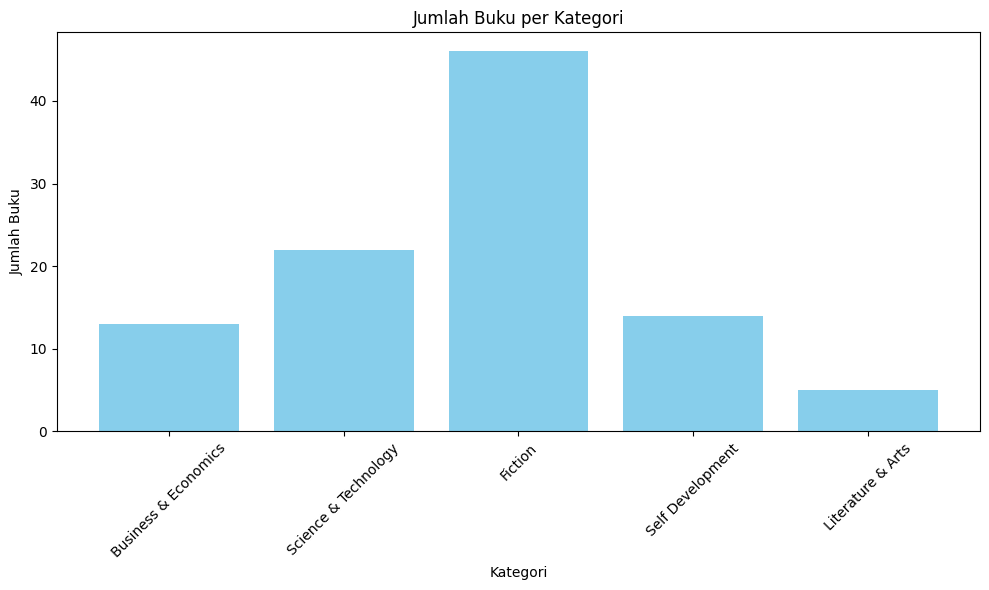

In [81]:
# TODO: Implement #1
df_books_per_category = conn.execute(
    """
    SELECT c.name AS category, COUNT(b.id) AS total_books
    FROM Books AS b
    JOIN Categories AS c ON b.category_id = c.id
    GROUP BY c.name;
    """
).df()

# Show Graph

# Membuat figure dengan ukuran yang sesuai
plt.figure(figsize=(10, 6))

# Membuat bar chart: sumbu x kategori, sumbu y jumlah buku
plt.bar(df_books_per_category['category'], df_books_per_category['total_books'], color='skyblue')

# Menambahkan label sumbu dan judul grafik
plt.xlabel('Kategori')
plt.ylabel('Jumlah Buku')
plt.title('Jumlah Buku per Kategori')

# Memutar label sumbu x agar lebih mudah dibaca
plt.xticks(rotation=45)

# Menampilkan grafik
plt.tight_layout()
plt.show()


- Terlihat bahwa kategori **Fiction** memiliki jumlah buku paling banyak, disusul **Science & Technology**, sementara **Literature & Arts** memiliki jumlah buku paling sedikit.
- Dari grafik ini, kita bisa menyimpulkan bahwa **Fiction** mendominasi koleksi buku, sementara kategori lain mungkin memerlukan penambahan stok atau promosi agar lebih seimbang.


#### Pertanyaan 2

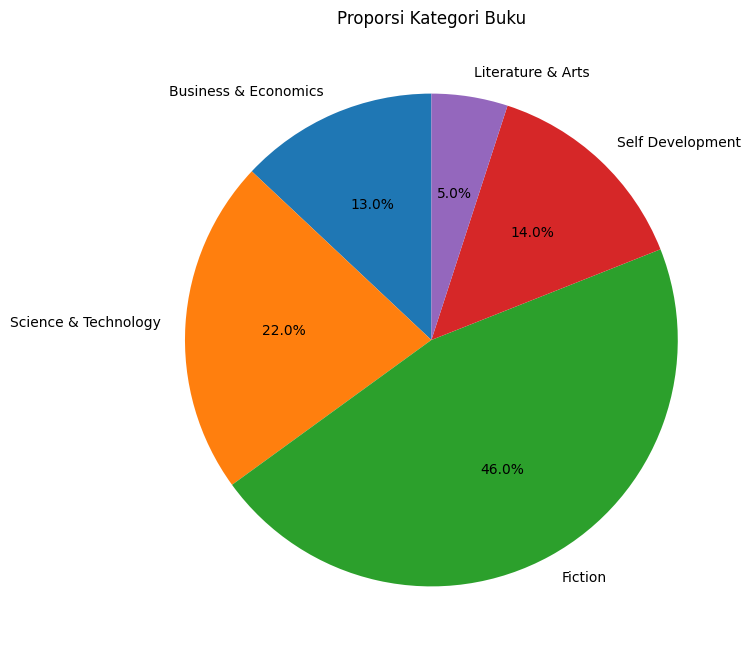

In [82]:
# TODO: Lanjutkan dari nomor 1, gunakan chart yang paling masuk akal!
# Membuat figure dengan ukuran yang sesuai
plt.figure(figsize=(8, 8))

# Membuat pie chart untuk proporsi kategori buku
plt.pie(
    df_books_per_category['total_books'], 
    labels=df_books_per_category['category'], 
    autopct='%1.1f%%',  # Menampilkan persentase dengan 1 digit desimal
    startangle=90      # Memulai pie chart dari sudut 90 derajat
)

# Menambahkan judul grafik
plt.title('Proporsi Kategori Buku')

# Menampilkan grafik
plt.show()


- Kategori **Fiction** mendominasi dengan porsi terbesar (46.0%).
- Diikuti oleh **Science & Technology** (22.0%), **Self Development** (14.0%), dan **Business & Economics** (13.0%).
- **Literature & Arts** memiliki porsi terkecil (5.0%).

#### Pertanyaan 3

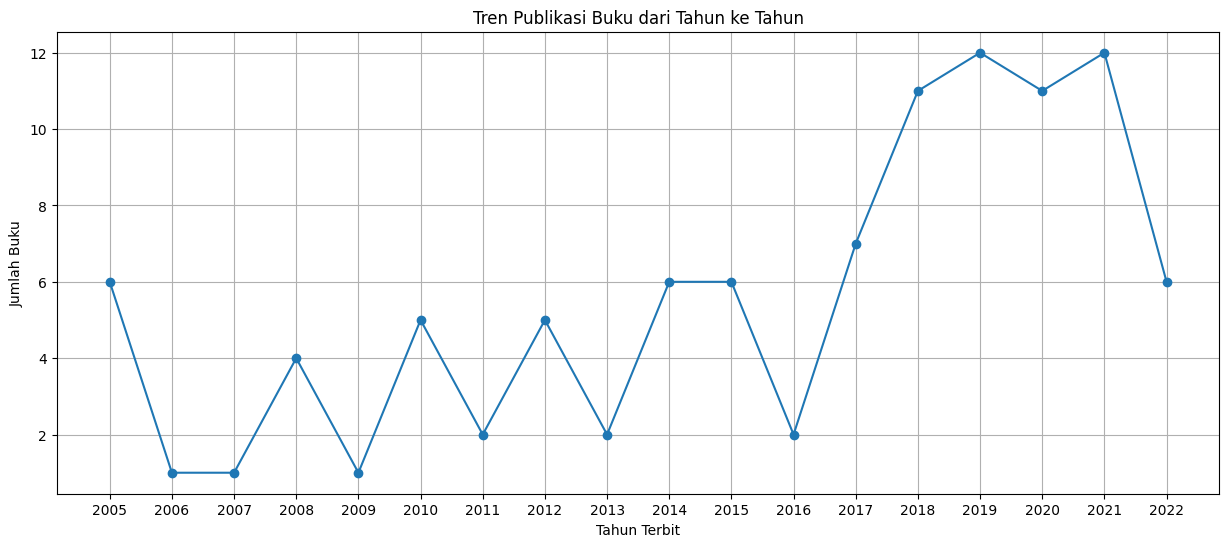

In [83]:
# TODO: Implement #3
from matplotlib.ticker import MaxNLocator
df_books_per_year = conn.execute(
    """
    SELECT published_year, COUNT(id) AS total_books
    FROM Books
    GROUP BY published_year
    ORDER BY published_year;
    """
).df()

# Show Graph
plt.figure(figsize=(15, 6))
plt.plot(df_books_per_year['published_year'], df_books_per_year['total_books'], marker='o', linestyle='-')
plt.xlabel('Tahun Terbit')
plt.ylabel('Jumlah Buku')
plt.title('Tren Publikasi Buku dari Tahun ke Tahun')
plt.grid(True)

# Mendapatkan rentang tahun
min_year = df_books_per_year['published_year'].min()
max_year = df_books_per_year['published_year'].max()

# Menentukan tick dari tahun minimum sampai maksimum
plt.xticks(range(min_year, max_year + 1))

plt.show()


- Terlihat adanya **fluktuasi** jumlah buku yang diterbitkan setiap tahunnya, dengan beberapa tahun memiliki jumlah yang cukup rendah.
- Puncak jumlah publikasi tampak terjadi sekitar tahun 2019 dan 2021 dengan jumlah mencapai 12 buku.
- Setelah itu, terdapat sedikit penurunan di beberapa tahun berikutnya, namun masih berada pada rentang yang relatif tinggi dibandingkan tahun-tahun awal.
- Secara keseluruhan, **tren publikasi** menunjukkan **peningkatan** dibandingkan dengan periode awal (2005–2010), meskipun terdapat **variasi** dari tahun ke tahun serta penurunan di tahun 2022.


### 📌 Studi Kasus: Analisis Statistik untuk Buku dan Penulis

#### 📖 Latar Belakang

Setelah berhasil melakukan visualisasi data, langkah selanjutnya adalah melakukan analisis statistik untuk lebih mendalami karakteristik data buku dan penulis. Di BiblioNest, tim ingin memahami beberapa aspek seperti:

1. Tunjukkan distribusi tahun terbit buku. Bagaimana distribusi tersebut, apakah *skewed*? Apabila iya, positif atau negatif *skewed*?
2. 5 penulis buku yang terproduktif
3. Usia rata-rata penulis saat pertama kali menerbitkan buku.

#### Pertanyaan 1

In [84]:
# TODO: Implement #1

# Mengambil semua tahun terbit buku
df_books_per_year_dist = conn.execute(
    """
    SELECT published_year
    FROM Books
    """
).df()

# Melihat deskripsi statistik
print(df_books_per_year_dist.describe())

# Menghitung skewness
skew_value = df_books_per_year_dist['published_year'].skew()
print("Skewness:", skew_value)


       published_year
count      100.000000
mean      2015.970000
std          4.945062
min       2005.000000
25%       2012.750000
50%       2018.000000
75%       2020.000000
max       2022.000000
Skewness: -0.8291013519639723


**Penjelasan Statistik**

1. **Ukuran Pusat (Mean & Median)**  
   - **Mean (rata-rata)**: ~2015.97  
   - **Median (nilai tengah)**: 2018  
   Perbedaan antara mean yang lebih kecil daripada median mengindikasikan distribusi cenderung **left-skewed (negatif)**.

2. **Rentang Data**  
   - **Min (tahun terbit terendah)**: 2005  
   - **Max (tahun terbit tertinggi)**: 2022  
   Menunjukkan rentang penerbitan buku selama 17 tahun.

3. **Skewness (Kemiringan Distribusi)**  
   - **Nilai Skewness**: -0.829 (mendekati -1)  
   Nilai negatif menandakan ekor distribusi lebih panjang di sisi kiri, sementara mayoritas data berada di sisi kanan (tahun yang lebih baru).

4. **Persebaran (Standard Deviation)**  
   - **Std**: ~4.95  
   Mengindikasikan variasi tahun terbit buku sekitar ±5 tahun dari rata-rata.

5. **Interpretasi Singkat**  
   - Distribusi **left-skewed**: Lebih banyak buku terbit pada tahun-tahun **mendekati 2022**, sementara beberapa buku terbit lebih awal (2005–2010) membentuk ekor di sisi kiri.  
   - Rentang 2005–2022 dengan **median 2018** menunjukkan bahwa setengah dari buku dalam data diterbitkan **setelah tahun 2018**.


#### Pertanyaan 2

In [85]:
# TODO: Implement #2

df_top_5_authors = conn.execute(
    """
    SELECT a.name AS author_name, COUNT(ba.book_id) AS total_books
    FROM Authors a
    JOIN Book_Authors ba ON a.id = ba.author_id
    GROUP BY a.name
    ORDER BY total_books DESC
    LIMIT 5
    """
).df()

df_top_5_authors


,author_name,total_books
0,Emma Larsson,13
1,Aisha Ibrahim,12
2,William O'Connor,12
3,Maria Garcia Rodriguez,11
4,Nina Ivanova,11


- Data ini mengindikasikan bahwa Emma Larsson adalah penulis dengan jumlah publikasi terbanyak. Sementara William O'Connor dan Aisha Ibrahim berada di posisi berikutnya dengan 12 buku, menunjukkan produktivitas tinggi dari ketiganya. 
- Informasi ini bisa membantu tim untuk mengenali penulis yang paling aktif dan berpotensi untuk kerja sama atau promosi.

#### Pertanyaan 3

In [86]:
# TODO: Implement #3

df_author_first_publish_age = conn.execute(
    """
    SELECT
        a.id AS author_id,
        a.name AS author_name,
        MIN(b.published_year) AS first_publish_year,
        EXTRACT(YEAR FROM a.birthdate) AS birth_year,
        (MIN(b.published_year) - EXTRACT(YEAR FROM a.birthdate)) AS age_at_first_publish
    FROM Authors a
    JOIN Book_Authors ba ON a.id = ba.author_id
    JOIN Books b ON b.id = ba.book_id
    GROUP BY a.id, a.name, birth_year
    """
).df()

# Menampilkan data
df_author_first_publish_age


,author_id,author_name,first_publish_year,birth_year,age_at_first_publish
0,22,Aisha Ibrahim,2008,1984,24
1,30,Emma Larsson,2005,1986,19
2,15,Hassan Ahmed,2005,1976,29
3,25,William O'Connor,2005,1967,38
4,6,Michael A. Wilson,2005,1965,40
5,26,Fatima Al-Sayed,2005,1988,17
6,5,Emily Brooks,2006,1990,16
7,18,Anna Kowalski,2005,1986,19
8,14,Rachel B. Cohen,2010,1980,30
9,2,David R. Thompson,2005,1968,37


In [87]:
# Menghitung usia rata-rata
avg_age = df_author_first_publish_age['age_at_first_publish'].mean()
print("Usia rata-rata penulis saat pertama kali menerbitkan buku:", avg_age)

Usia rata-rata penulis saat pertama kali menerbitkan buku: 27.766666666666666
